In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [18]:
load_dotenv()

True

In [19]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=1.5)

In [20]:
# state

class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [21]:
def generate_joke(state: JokeState):

    prompt = f" Create a new, punchy, sarcastic one-liner about {state['topic']} that is funny, concise, and tweet-worthy."
    response = llm.invoke(prompt).content

    return {'joke': response}


In [22]:
def generate_explanation(state: JokeState):

    prompt = f"write a explanation for the joke - {state['joke']}"
    response = llm.invoke(prompt).content

    return {'explanation': response}

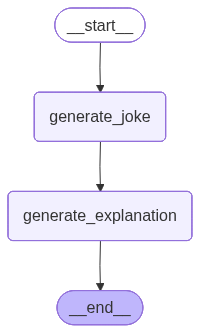

In [23]:
graph = StateGraph(JokeState)

# Add Node
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# Add Edges
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

# compile graph
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [42]:
config = {'configurable': {'thread_id': '1'}}
initital_state = {
    'topic': 'friends'
}

final_state = workflow.invoke(initital_state, config)

In [43]:
final_state

{'topic': 'friends',
 'joke': '"Friends: the adult version of why I can’t have nice things—choose your chaos wisely."',
 'explanation': 'Sure! Here’s an explanation for the joke:\n\nThe joke plays on the common phrase “Why I can’t have nice things,” which people often say when others accidentally break or ruin something valuable or fragile they own. It humorously implies that \'Friends\' are like an adult-sized version of that problem — meaning that adult friendships, while important and cherished, can also bring chaos, drama, or unpredictable situations that complicate life in ways similar to how kids or younger people might ruin nice things. The punchline, “choose your chaos wisely,” suggests that while friendships inevitably involve some level of messiness or trouble, you should thoughtfully decide which friends (or "chaos") to welcome into your life because they impact your happiness and “nice things” as an adult.\n\nIn other words, the joke highlights the complexity and sometimes 

In [44]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'friends', 'joke': '"Friends: the adult version of why I can’t have nice things—choose your chaos wisely."', 'explanation': 'Sure! Here’s an explanation for the joke:\n\nThe joke plays on the common phrase “Why I can’t have nice things,” which people often say when others accidentally break or ruin something valuable or fragile they own. It humorously implies that \'Friends\' are like an adult-sized version of that problem — meaning that adult friendships, while important and cherished, can also bring chaos, drama, or unpredictable situations that complicate life in ways similar to how kids or younger people might ruin nice things. The punchline, “choose your chaos wisely,” suggests that while friendships inevitably involve some level of messiness or trouble, you should thoughtfully decide which friends (or "chaos") to welcome into your life because they impact your happiness and “nice things” as an adult.\n\nIn other words, the joke highlights the comple

In [46]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'friends', 'joke': '"Friends: the adult version of why I can’t have nice things—choose your chaos wisely."', 'explanation': 'Sure! Here’s an explanation for the joke:\n\nThe joke plays on the common phrase “Why I can’t have nice things,” which people often say when others accidentally break or ruin something valuable or fragile they own. It humorously implies that \'Friends\' are like an adult-sized version of that problem — meaning that adult friendships, while important and cherished, can also bring chaos, drama, or unpredictable situations that complicate life in ways similar to how kids or younger people might ruin nice things. The punchline, “choose your chaos wisely,” suggests that while friendships inevitably involve some level of messiness or trouble, you should thoughtfully decide which friends (or "chaos") to welcome into your life because they impact your happiness and “nice things” as an adult.\n\nIn other words, the joke highlights the compl